# 🛒 Pandas Assignment — E-Commerce Sales Analysis
### Olist Brazilian E-Commerce Dataset

Welcome to the practical assignment for the Pandas Complete Guide. You will perform a full end-to-end analysis of a real e-commerce company's sales data, applying every pandas technique covered in the lesson notebook.

---

## 🎯 Learning Objectives
By the end of this assignment you will have:
- **Loaded and merged** 7+ related CSV tables (orders, customers, products, sellers, payments, items, reviews)
- **Handled missing values** with multiple strategies based on context
- **Joined and merged** DataFrames using every join type (inner, left, right, outer)
- **Performed group-by aggregations** for business KPIs
- **Conducted time-series analysis** including resampling, rolling windows, and trend detection
- **Produced a final business report** with concrete, data-backed insights

---

## 📦 The Dataset

We use the **Olist Brazilian E-Commerce Public Dataset** — 100,000+ real (anonymized) orders from 2016–2018, organized across 9 interrelated tables. This is one of the most popular publicly available sales datasets and is widely used in data science portfolios.

### Schema overview
```
                  ┌─────────────┐
                  │  customers  │
                  └──────┬──────┘
                         │ customer_id
                  ┌──────▼──────┐
        ┌────────►│   orders    │◄────────┐
        │         └──────┬──────┘         │
        │ order_id       │ order_id       │ order_id
┌───────┴──────┐  ┌──────▼─────┐   ┌──────┴────────┐
│   reviews    │  │ order_items │   │   payments   │
└──────────────┘  └─┬─────────┬─┘   └──────────────┘
                    │         │
              product_id   seller_id
                    │         │
              ┌─────▼───┐ ┌───▼────┐
              │ products│ │ sellers│
              └─────────┘ └────────┘
```

### 📥 How to obtain the dataset

**Option A — Real Olist data (recommended for portfolio work):**
1. Visit https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
2. Sign in to Kaggle (free) and click **Download** to get `archive.zip` (~45 MB)
3. Extract and place all CSV files into a folder named `olist_data/` in the same directory as this notebook
4. Set `USE_REAL_DATA = True` in the setup cell below

**Option B — Synthetic equivalent (run immediately):**
- Leave `USE_REAL_DATA = False` (default)
- The notebook will generate a smaller synthetic dataset with the same schema and column names
- All assignment questions and code work identically on both datasets

> **Tip:** start with Option B to build your code. If you want to extend the work into a portfolio piece, swap to Option A — your code will keep working on the larger real dataset.

---

## 📝 How to Submit

Fill in every code cell marked `# Your code here`. Add markdown cells with your interpretation wherever a question asks **"explain"** or **"comment"**.

Each section has its own **rubric** at the top — check yourself before moving on.

> ⏱ **Estimated time:** 6–10 hours of focused work depending on depth of exploration.

---
## 🔧 Setup

Run these cells first. They import libraries and either load the real Olist files or generate synthetic equivalents.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

# ────────────────────────────────────────────────────────────────────
# SWITCH BETWEEN REAL OLIST DATA AND SYNTHETIC DATA
# ────────────────────────────────────────────────────────────────────
USE_REAL_DATA = True   # set to True if you've downloaded Olist from Kaggle
DATA_DIR = 'dataset/'  # folder containing the Olist CSVs (real data only)

print(f"USE_REAL_DATA = {USE_REAL_DATA}")
print(f"pandas = {pd.__version__}")

USE_REAL_DATA = True
pandas = 2.3.3


### Synthetic data generator (only runs if `USE_REAL_DATA = False`)

This builds 7 CSV files with the same column names as the real Olist dataset. Records are interrelated and span 2 years so the time-series questions are meaningful.

In [7]:
import os

if not USE_REAL_DATA:
    rng = np.random.default_rng(42)
    os.makedirs('synthetic_olist', exist_ok=True)

    # ── 1. CUSTOMERS ────────────────────────────────────────────────
    n_customers = 3000
    states = ['SP','RJ','MG','RS','PR','SC','BA','DF','GO','PE','CE','PA','MA','MT','MS']
    state_p = [0.42,0.13,0.12,0.06,0.05,0.04,0.04,0.03,0.03,0.02,0.02,0.01,0.01,0.01,0.01]
    cities = {
        'SP':['sao paulo','campinas','santos','ribeirao preto','sorocaba'],
        'RJ':['rio de janeiro','niteroi','duque de caxias'],
        'MG':['belo horizonte','uberlandia','contagem','juiz de fora'],
        'RS':['porto alegre','caxias do sul','pelotas'],
        'PR':['curitiba','londrina','maringa'],
        'SC':['florianopolis','joinville','blumenau'],
        'BA':['salvador','feira de santana'],
        'DF':['brasilia'],
        'GO':['goiania','aparecida de goiania'],
        'PE':['recife','olinda'],
        'CE':['fortaleza','caucaia'],
        'PA':['belem','ananindeua'],
        'MA':['sao luis'],
        'MT':['cuiaba','varzea grande'],
        'MS':['campo grande'],
    }
    cust_states = rng.choice(states, n_customers, p=state_p)
    customers = pd.DataFrame({
        'customer_id': [f'cust_{i:06d}' for i in range(n_customers)],
        'customer_unique_id': [f'uniq_{rng.integers(0, n_customers*0.85):06d}' for _ in range(n_customers)],
        'customer_zip_code_prefix': rng.integers(1000, 99999, n_customers),
        'customer_city': [rng.choice(cities[s]) for s in cust_states],
        'customer_state': cust_states,
    })
    customers.to_csv('synthetic_olist/olist_customers_dataset.csv', index=False)

    # ── 2. SELLERS ──────────────────────────────────────────────────
    n_sellers = 250
    sel_states = rng.choice(states, n_sellers, p=state_p)
    sellers = pd.DataFrame({
        'seller_id': [f'sell_{i:04d}' for i in range(n_sellers)],
        'seller_zip_code_prefix': rng.integers(1000, 99999, n_sellers),
        'seller_city': [rng.choice(cities[s]) for s in sel_states],
        'seller_state': sel_states,
    })
    sellers.to_csv('synthetic_olist/olist_sellers_dataset.csv', index=False)

    # ── 3. PRODUCTS ────────────────────────────────────────────────
    n_products = 800
    categories = ['cama_mesa_banho','beleza_saude','esporte_lazer','informatica_acessorios',
                  'moveis_decoracao','utilidades_domesticas','relogios_presentes','telefonia',
                  'automotivo','brinquedos','cool_stuff','ferramentas_jardim','perfumaria',
                  'bebes','eletronicos','livros_interesse_geral']
    products = pd.DataFrame({
        'product_id': [f'prod_{i:05d}' for i in range(n_products)],
        'product_category_name': rng.choice(categories, n_products),
        'product_name_lenght': rng.integers(20, 80, n_products).astype(float),
        'product_description_lenght': rng.integers(100, 4000, n_products).astype(float),
        'product_photos_qty': rng.integers(1, 8, n_products).astype(float),
        'product_weight_g': rng.integers(50, 30000, n_products).astype(float),
        'product_length_cm': rng.integers(10, 100, n_products).astype(float),
        'product_height_cm': rng.integers(2, 80, n_products).astype(float),
        'product_width_cm': rng.integers(5, 80, n_products).astype(float),
    })
    # Inject realistic missingness
    for col in ['product_category_name','product_weight_g','product_length_cm','product_height_cm','product_width_cm']:
        miss_idx = rng.choice(n_products, size=int(n_products*0.03), replace=False)
        products.loc[miss_idx, col] = np.nan
    products.to_csv('synthetic_olist/olist_products_dataset.csv', index=False)

    # ── 4. ORDERS ────────────────────────────────────────────────
    n_orders = 7000
    # Build datetime distribution: increasing volume over time + weekly seasonality
    start = pd.Timestamp('2017-01-01')
    days_range = 730
    # weight days so volume grows over time and dips on weekends slightly
    day_weights = []
    for d in range(days_range):
        date = start + pd.Timedelta(days=d)
        base = 0.5 + d/days_range  # linear growth
        if date.weekday() in [5, 6]:
            base *= 0.85  # slightly lower weekend volume
        # holiday spike around November (Black Friday)
        if date.month == 11 and 20 <= date.day <= 28:
            base *= 2.5
        day_weights.append(base)
    day_weights = np.array(day_weights) / sum(day_weights)
    chosen_days = rng.choice(days_range, n_orders, p=day_weights)
    purchase_ts = [start + pd.Timedelta(days=int(d), hours=int(rng.integers(8,23)),
                                         minutes=int(rng.integers(0,60))) for d in chosen_days]
    purchase_ts = pd.to_datetime(purchase_ts)

    statuses = rng.choice(['delivered','shipped','canceled','invoiced','processing'],
                           n_orders, p=[0.92, 0.03, 0.03, 0.01, 0.01])
    approved_ts = [t + pd.Timedelta(hours=int(rng.integers(0,48))) for t in purchase_ts]
    carrier_ts = [t + pd.Timedelta(days=int(rng.integers(1,7))) for t in approved_ts]
    delivered_ts = [t + pd.Timedelta(days=int(rng.integers(2,15))) for t in carrier_ts]
    estimated_ts = [t + pd.Timedelta(days=int(rng.integers(10,25))) for t in purchase_ts]

    orders = pd.DataFrame({
        'order_id': [f'ord_{i:06d}' for i in range(n_orders)],
        'customer_id': rng.choice(customers['customer_id'], n_orders),
        'order_status': statuses,
        'order_purchase_timestamp': purchase_ts,
        'order_approved_at': approved_ts,
        'order_delivered_carrier_date': carrier_ts,
        'order_delivered_customer_date': delivered_ts,
        'order_estimated_delivery_date': estimated_ts,
    })
    # Inject missingness: non-delivered orders have missing delivery dates
    orders.loc[orders['order_status'] != 'delivered', 'order_delivered_customer_date'] = pd.NaT
    orders.loc[orders['order_status'].isin(['canceled','processing','invoiced']),
               'order_delivered_carrier_date'] = pd.NaT
    # A few approved_at missing too
    miss_idx = rng.choice(n_orders, size=int(n_orders*0.005), replace=False)
    orders.loc[miss_idx, 'order_approved_at'] = pd.NaT
    orders.to_csv('synthetic_olist/olist_orders_dataset.csv', index=False)

    # ── 5. ORDER ITEMS ────────────────────────────────────────────────
    item_rows = []
    for i, oid in enumerate(orders['order_id']):
        n_items = rng.choice([1, 1, 1, 1, 2, 2, 3], p=[0.55,0.15,0.05,0.05,0.12,0.05,0.03])
        purchase_t = orders.iloc[i]['order_purchase_timestamp']
        for item_n in range(1, n_items + 1):
            price = round(float(rng.lognormal(4.3, 0.7)), 2)
            freight = round(price * float(rng.uniform(0.05, 0.25)), 2)
            item_rows.append({
                'order_id': oid,
                'order_item_id': item_n,
                'product_id': rng.choice(products['product_id']),
                'seller_id': rng.choice(sellers['seller_id']),
                'shipping_limit_date': purchase_t + pd.Timedelta(days=int(rng.integers(2, 8))),
                'price': price,
                'freight_value': freight,
            })
    order_items = pd.DataFrame(item_rows)
    order_items.to_csv('synthetic_olist/olist_order_items_dataset.csv', index=False)

    # ── 6. PAYMENTS ──────────────────────────────────────────────────
    payment_rows = []
    for oid in orders['order_id']:
        n_pay = rng.choice([1, 1, 1, 2], p=[0.92, 0.04, 0.02, 0.02])
        order_total = order_items[order_items['order_id'] == oid][['price','freight_value']].sum().sum()
        for seq in range(1, n_pay + 1):
            pay_type = rng.choice(['credit_card','boleto','voucher','debit_card'], p=[0.74,0.19,0.05,0.02])
            installments = rng.choice([1,2,3,4,5,6,8,10], p=[0.5,0.12,0.10,0.08,0.06,0.05,0.05,0.04]) if pay_type=='credit_card' else 1
            payment_rows.append({
                'order_id': oid,
                'payment_sequential': seq,
                'payment_type': pay_type,
                'payment_installments': int(installments),
                'payment_value': round(float(order_total / n_pay), 2),
            })
    payments = pd.DataFrame(payment_rows)
    payments.to_csv('synthetic_olist/olist_order_payments_dataset.csv', index=False)

    # ── 7. REVIEWS ──────────────────────────────────────────────────
    review_rows = []
    for i, oid in enumerate(orders['order_id']):
        if rng.random() < 0.85:  # 85% have a review
            score = rng.choice([1,2,3,4,5], p=[0.10, 0.05, 0.10, 0.20, 0.55])
            create_ts = orders.iloc[i]['order_purchase_timestamp'] + pd.Timedelta(days=int(rng.integers(5,25)))
            answer_ts = create_ts + pd.Timedelta(days=int(rng.integers(0,10))) if rng.random() < 0.7 else pd.NaT
            review_rows.append({
                'review_id': f'rev_{i:06d}',
                'order_id': oid,
                'review_score': int(score),
                'review_comment_title': rng.choice(['Excelente','Bom','Recomendo','Péssimo','Otimo', None],
                                                   p=[0.15,0.15,0.10,0.05,0.10,0.45]),
                'review_comment_message': rng.choice(['Produto chegou rapido','Recomendo a todos',
                                                       'Produto com defeito','Atrasou a entrega',
                                                       'Otima qualidade', None],
                                                      p=[0.18,0.12,0.05,0.05,0.15,0.45]),
                'review_creation_date': create_ts,
                'review_answer_timestamp': answer_ts,
            })
    reviews = pd.DataFrame(review_rows)
    reviews.to_csv('synthetic_olist/olist_order_reviews_dataset.csv', index=False)

    # ── 8. CATEGORY TRANSLATION ──────────────────────────────────────
    translation = pd.DataFrame({
        'product_category_name': categories,
        'product_category_name_english': [
            'bed_bath_table','health_beauty','sports_leisure','computers_accessories',
            'furniture_decor','housewares','watches_gifts','telephony',
            'auto','toys','cool_stuff','garden_tools','perfumery',
            'baby','electronics','books_general_interest'
        ],
    })
    translation.to_csv('synthetic_olist/product_category_name_translation.csv', index=False)

    DATA_DIR = 'synthetic_olist/'
    print('✅ Synthetic dataset generated in:', DATA_DIR)
    print('Files written:')
    for f in sorted(os.listdir(DATA_DIR)):
        print(f'   {f}  ({os.path.getsize(DATA_DIR + f)/1024:.1f} KB)')

### Load all the CSVs

In [3]:
customers      = pd.read_csv(DATA_DIR + 'olist_customers_dataset.csv')
orders         = pd.read_csv(DATA_DIR + 'olist_orders_dataset.csv')
order_items    = pd.read_csv(DATA_DIR + 'olist_order_items_dataset.csv')
products       = pd.read_csv(DATA_DIR + 'olist_products_dataset.csv')
sellers        = pd.read_csv(DATA_DIR + 'olist_sellers_dataset.csv')
payments       = pd.read_csv(DATA_DIR + 'olist_order_payments_dataset.csv')
reviews        = pd.read_csv(DATA_DIR + 'olist_order_reviews_dataset.csv')
translation    = pd.read_csv(DATA_DIR + 'product_category_name_translation.csv')

# Parse datetime columns up front
for col in ['order_purchase_timestamp','order_approved_at',
            'order_delivered_carrier_date','order_delivered_customer_date',
            'order_estimated_delivery_date']:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

reviews['review_creation_date']     = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp']  = pd.to_datetime(reviews['review_answer_timestamp'], errors='coerce')
order_items['shipping_limit_date']  = pd.to_datetime(order_items['shipping_limit_date'])

print('All 8 tables loaded:')
for name, t in [('customers',customers),('orders',orders),('order_items',order_items),
                ('products',products),('sellers',sellers),('payments',payments),
                ('reviews',reviews),('translation',translation)]:
    print(f'  {name:15s} {t.shape}')

All 8 tables loaded:
  customers       (3000, 5)
  orders          (7000, 8)
  order_items     (8593, 7)
  products        (800, 9)
  sellers         (250, 4)
  payments        (7139, 5)
  reviews         (5963, 7)
  translation     (16, 2)


---
# Part 1 — Data Loading & Inspection

> **Rubric:** for each table you should be able to state (a) what one row represents, (b) the primary key, (c) the foreign keys that link to other tables, (d) the data types of each column, (e) the count of missing values per column.

### Q1.1 — Display the first 5 rows of every table.

In [5]:
# Display first 5 rows of every table
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,cust_000000,uniq_001578,45150,londrina,PR
1,cust_000001,uniq_002114,2866,niteroi,RJ
2,cust_000002,uniq_001632,67639,salvador,BA
3,cust_000003,uniq_001514,46046,porto alegre,RS
4,cust_000004,uniq_001191,77383,santos,SP


In [8]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,ord_000000,cust_001767,delivered,2018-10-14 18:44:00,2018-10-14 18:44:00,2018-10-19 18:44:00,2018-10-23 18:44:00,2018-11-01 18:44:00
1,ord_000001,cust_002696,delivered,2018-08-27 15:38:00,2018-08-27 17:38:00,2018-08-28 17:38:00,2018-09-02 17:38:00,2018-09-18 15:38:00
2,ord_000002,cust_000938,delivered,2018-05-30 16:41:00,2018-05-31 18:41:00,2018-06-02 18:41:00,2018-06-07 18:41:00,2018-06-20 16:41:00
3,ord_000003,cust_002656,delivered,2018-02-16 14:39:00,2018-02-17 14:39:00,2018-02-22 14:39:00,2018-02-27 14:39:00,2018-03-05 14:39:00
4,ord_000004,cust_001532,delivered,2018-09-06 17:38:00,2018-09-07 08:38:00,2018-09-08 08:38:00,2018-09-14 08:38:00,2018-09-17 17:38:00


In [11]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,ord_000000,1,prod_00658,sell_0139,2018-10-18 18:44:00,115.30,19.73
1,ord_000000,2,prod_00707,sell_0165,2018-10-19 18:44:00,75.39,4.15
2,ord_000001,1,prod_00063,sell_0188,2018-09-03 15:38:00,94.17,18.35
3,ord_000001,2,prod_00154,sell_0051,2018-09-03 15:38:00,20.08,3.52
4,ord_000002,1,prod_00415,sell_0215,2018-06-02 16:41:00,138.35,27.24


### Q1.2 — For each table, print `.shape`, `.dtypes`, and `.info()`.

In [4]:
# Print shape, dtypes, and info for each table
tables = [
    ("customers", customers),
    ("orders", orders),
    ("order_items", order_items),
    ("products", products),
    ("sellers", sellers),
    ("payments", payments),
    ("reviews", reviews),
    ("translation", translation)
]
for name, df in tables:
    print(f"Table name: {name}")
    print(f".shape: {df.shape}")
    print(f".dtypes: {df.dtypes}")
    df.info()

Table name: customers
.shape: (3000, 5)
.dtypes: customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               3000 non-null   object
 1   customer_unique_id        3000 non-null   object
 2   customer_zip_code_prefix  3000 non-null   int64 
 3   customer_city             3000 non-null   object
 4   customer_state            3000 non-null   object
dtypes: int64(1), object(4)
memory usage: 117.3+ KB
Table name: orders
.shape: (7000, 8)
.dtypes: order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         dat

### Q1.3 — Identify keys
For each table, write down (as a markdown comment in a cell below) what the **primary key** is and what **foreign keys** link it to other tables.

For example, in `orders`:
- Primary key: `order_id`
- Foreign keys: `customer_id` → `customers`

In [23]:
# Identification of primary keys and foreign keys for each table:
# - customers: PK is customer_id, no FKs present.
# - orders: PK is order_id, FK is customer_id -> customers table.
# - order_items: PK is compound (order_id, order_item_id), FKs are order_id -> orders, product_id -> products, seller_id -> sellers.
# - products: PK is product_id, FK is product_category_name -> translation table.
# - sellers: PK is seller_id, no FKs present.
# - payments: PK is compound (order_id, payment_sequential), FK is order_id -> orders table.
# - reviews: PK is review_id, FK is order_id -> orders table.
# - translation: PK is product_category_name, no FKs present.

### Q1.4 — How many unique customers, sellers, products, and orders are there?
Use `.nunique()` rather than `len()` — they differ if a table has duplicates.

In [35]:
# Unique customers, sellers, products, and orders
print(customers['customer_unique_id'].nunique())

1767


In [38]:
print(sellers['seller_id'].nunique())

250


In [40]:
print(products['product_id'].nunique())

800


In [42]:
print(orders['order_id'].nunique())

7000


### Q1.5 — What date range does the dataset cover?
Compute the min and max of `order_purchase_timestamp` and the total span in days.

In [44]:
# Date range and total span in days
min_date = orders['order_purchase_timestamp'].min()
min_date

Timestamp('2017-01-01 10:08:00')

In [46]:
max_date = orders['order_purchase_timestamp'].max()
max_date

Timestamp('2018-12-31 21:44:00')

In [47]:
total_span_days = (max_date - min_date)
total_span_days

Timedelta('729 days 11:36:00')

### Q1.6 — Memory usage
Compute the **total memory** used by all 8 DataFrames combined. Which table uses the most memory?

In [49]:
# Compute memory usage of each table
total_memory = 0
for name, df in tables:
    memory = df.memory_usage(deep=True).sum()
    total_memory += memory

In [54]:
total_memory

np.int64(6646866)

In [59]:
largest_table = ""
largest_memory = 0

for name, df in tables:
    memory = df.memory_usage(deep=True).sum()

    if memory > largest_memory:
        largest_memory = memory
        largest_table = name
print(largest_table)
print(largest_memory)

order_items
1787476


### Q1.7 — Order status distribution
What are the unique values of `order_status` in the orders table, and how many rows fall into each? Sort by count, descending. What proportion of orders were ultimately delivered?

In [63]:
unique_order_status = orders['order_status'].unique()
unique_order_status

array(['delivered', 'canceled', 'shipped', 'processing', 'invoiced'],
      dtype=object)

order_status
delivered     6448
canceled       224
shipped        191
invoiced        72
processing      65
Name: count, dtype: int64

Proportion delivered: 92.11%


In [64]:
orders['order_status'].value_counts()

order_status
delivered     6448
canceled       224
shipped        191
invoiced        72
processing      65
Name: count, dtype: int64

In [69]:
orders['order_status'].value_counts().sort_values(ascending=False) 

order_status
delivered     6448
canceled       224
shipped        191
invoiced        72
processing      65
Name: count, dtype: int64

In [71]:
orders['order_status'].value_counts().sort_values(ascending=True)

order_status
processing      65
invoiced        72
shipped        191
canceled       224
delivered     6448
Name: count, dtype: int64

---
# Part 2 — Handling Missing Values

> **Rubric:** for every column that has missing values, you should be able to justify *why* it's missing and *what* you do about it. There is no single right answer — context matters.

### Q2.1 — Build a missing-value summary
Produce a DataFrame with one row per (table, column) pair where missing values exist. Columns: `table`, `column`, `n_missing`, `pct_missing`. Sort descending by `pct_missing`.

**Hint:**
```python
summary = []
for name, t in [('customers', customers), ('orders', orders), ...]:
    miss = t.isna().sum()
    for col, n in miss[miss > 0].items():
        summary.append({'table': name, 'column': col, 'n_missing': n, 'pct_missing': n/len(t)*100})
pd.DataFrame(summary).sort_values('pct_missing', ascending=False)
```

In [8]:
summary = []

for name, t in [
    ('customers', customers),
    ('orders', orders),
    ('order_items', order_items),
    ('products', products),
    ('sellers', sellers),
    ('payments', payments),
    ('reviews', reviews),
    ('translation', translation)
]:
    miss = t.isna().sum()
    for col, n in miss[miss>0].items():
        summary.append({
            'table': name,
            'column':col,
            'n_missing':n,
            'pct_missing':n/len(t)*100})
pd.DataFrame(summary).sort_values('pct_missing', ascending=False)

,table,column,n_missing,pct_missing
8,reviews,review_comment_title,2703,45.329532
9,reviews,review_comment_message,2633,44.155626
10,reviews,review_answer_timestamp,1744,29.247023
2,orders,order_delivered_customer_date,552,7.885714
1,orders,order_delivered_carrier_date,361,5.157143
3,products,product_category_name,24,3.000000
4,products,product_weight_g,24,3.000000
5,products,product_length_cm,24,3.000000
6,products,product_height_cm,24,3.000000
7,products,product_width_cm,24,3.000000


### Q2.2 — Visualize the missing-value pattern in `orders`
Build a heatmap of `orders.isna()`. Comment on what you see.

In [12]:
# Heatmap of orders.isna()
orders.isna().sum()

order_id                           0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
order_approved_at                 35
order_delivered_carrier_date     361
order_delivered_customer_date    552
order_estimated_delivery_date      0
dtype: int64

In [13]:
orders.isna()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
6995,False,False,False,False,False,False,False,False
6996,False,False,False,False,False,False,False,False
6997,False,False,False,False,False,False,False,False
6998,False,False,False,False,False,False,False,False


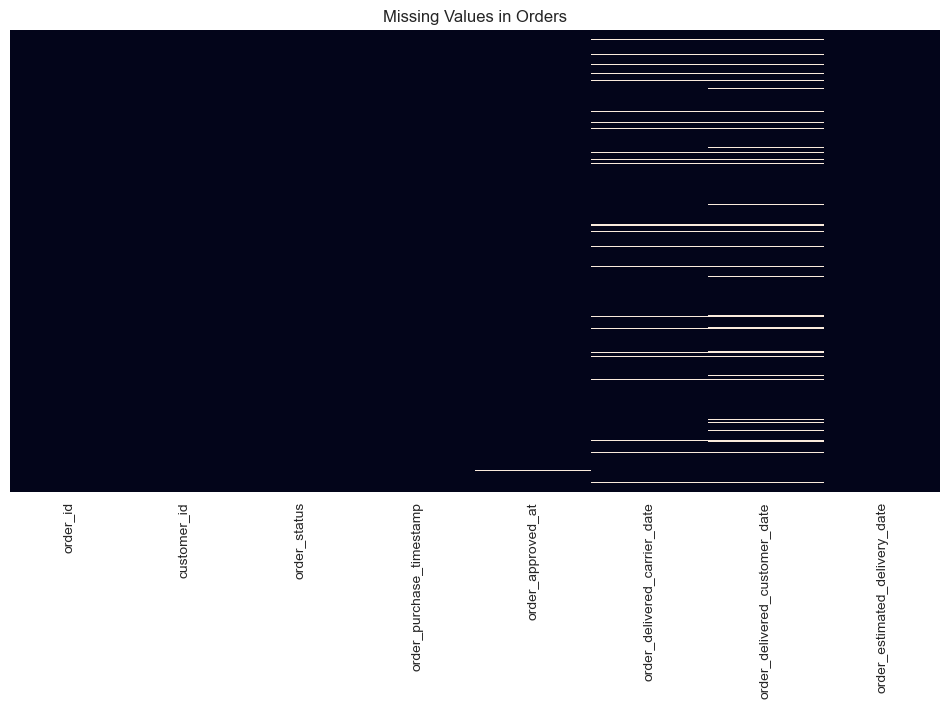

In [15]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    orders.isna(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values in Orders")
plt.show()

### Q2.3 — Explain the missingness in `orders.order_delivered_customer_date`
Group the orders DataFrame by `order_status` and count how many rows have `order_delivered_customer_date` missing for each status. Write a one-sentence interpretation: **why** would non-delivered orders have a missing delivery date?

In [27]:
orders['order_status'].value_counts()

order_status
delivered     6448
canceled       224
shipped        191
invoiced        72
processing      65
Name: count, dtype: int64

In [32]:
orders.groupby('order_status')['order_delivered_customer_date'].apply(lambda x: x.isna().sum())

order_status
canceled      224
delivered       0
invoiced       72
processing     65
shipped       191
Name: order_delivered_customer_date, dtype: int64

### Q2.4 — Impute `order_approved_at`
A small number of rows have a missing `order_approved_at` despite being delivered. Impute these with the **mean approval delay** (mean of `order_approved_at - order_purchase_timestamp`) added to the purchase timestamp. Verify there are no more missing approved-at values among delivered orders afterwards.

In [69]:
approved_orders = orders[orders['order_approved_at'].notna()]

In [71]:
approval_delay = (approved_orders['order_approved_at'] - approved_orders['order_purchase_timestamp'])

In [72]:
mean_approval_delay = approval_delay.mean()
mean_approval_delay

Timedelta('0 days 23:13:16.496769562')

In [74]:
missing_approved_delivered = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_approved_at'].isna())
]

In [75]:
missing_approved_delivered.shape

(0, 8)

In [76]:
orders.loc[
    (orders['order_status'] == 'delivered') &
    (orders['order_approved_at'].isna()),
    'order_approved_at'
] = (
    orders.loc[
        (orders['order_status'] == 'delivered') &
        (orders['order_approved_at'].isna()),
        'order_purchase_timestamp'
    ] + mean_approval_delay
)

In [77]:
orders.loc[
    orders['order_status'] == 'delivered',
    'order_approved_at'
].isna().sum()

np.int64(0)

### Q2.5 — Decide what to do about missing `product_category_name`
A few products are missing their category name. Show how many. Pick one of these strategies and apply it:
- (a) Fill with `'unknown'`
- (b) Drop those rows
- (c) Impute based on similar products (advanced)

Justify your choice in a comment.

In [5]:
products['product_category_name'].isna().sum()

np.int64(24)

In [7]:
products['product_category_name'] = products['product_category_name'].fillna("unknown")

In [8]:
products['product_category_name'].isna().sum()

np.int64(0)

### Q2.6 — Missing review comments
Reviews have many missing `review_comment_message` values. Is this missingness **informative** (do customers without comments give different scores than customers with comments)? Test this by computing the mean `review_score` for each group.

In [9]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5963 entries, 0 to 5962
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                5963 non-null   object        
 1   order_id                 5963 non-null   object        
 2   review_score             5963 non-null   int64         
 3   review_comment_title     3260 non-null   object        
 4   review_comment_message   3330 non-null   object        
 5   review_creation_date     5963 non-null   datetime64[ns]
 6   review_answer_timestamp  4219 non-null   datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 326.2+ KB


In [10]:
reviews.groupby(reviews['review_comment_message'].isna())['review_score'].mean()

review_comment_message
False    4.011712
True     4.064185
Name: review_score, dtype: float64

In [11]:
reviews.groupby(reviews['review_comment_message'].notna())['review_score'].mean()

review_comment_message
False    4.064185
True     4.011712
Name: review_score, dtype: float64

---
# Part 3 — Merging & Joining Datasets

> **Rubric:** you should choose the right join type for each task, predict the resulting row count before merging, and verify it after.

### Q3.1 — Inner join: orders + customers
Inner-join `orders` with `customers` on `customer_id`. How many rows result? Are there any orphan rows (orders without a customer, or vice versa)? Use `indicator=True` to check.

In [17]:
# Inner join orders and customers
orders_cust_inner = pd.merge(orders, customers, on='customer_id', how='inner')                 # Inner join orders and customers
print(f"Inner join row count: {orders_cust_inner.shape[0]}")                                   # Print inner join row count
orders_cust_outer = pd.merge(orders, customers, on='customer_id', how='outer', indicator=True) # Outer join with merge indicator
print("Orphan check results:")                                                                 # Label output section
print(orders_cust_outer['_merge'].value_counts())                                              # Print merge result distribution


Inner join row count: 7000
Orphan check results:
_merge
both          7000
right_only     289
left_only        0
Name: count, dtype: int64


### Q3.2 — Left join: order_items + products
Left-join `order_items` with `products` on `product_id`. After joining, how many rows have a missing `product_category_name`? Were these missing before the join, or are they introduced by the join itself?

In [18]:
# Left join order_items and products
items_prod = pd.merge(order_items, products, on='product_id', how='left')                     # Perform left join
missing_cat_post = items_prod['product_category_name'].isna().sum()                            # Check missing categories in merged df
print(f"Rows with missing product_category_name after join: {missing_cat_post}")               # Print result size
missing_in_products = products['product_category_name'].isna().sum()                           # Check missing categories in products df
print(f"Rows with missing category in products table: {missing_in_products}")                 # Verify if original categories were missing


Rows with missing product_category_name after join: 0
Rows with missing category in products table: 0


### Q3.3 — Translate categories to English
Left-join the result of Q3.2 with `translation` to add an English category name. Verify that no rows were lost.

In [19]:
# Left join items_prod with translation
items_prod_eng = pd.merge(items_prod, translation, on='product_category_name', how='left')     # Translate product categories to English
print(f"Shape before translation join: {items_prod.shape}, after: {items_prod_eng.shape}")     # Compare shape to verify no rows were lost
print(f"Missing english names: {items_prod_eng['product_category_name_english'].isna().sum()}") # Check count of missing English translations


Shape before translation join: (8593, 15), after: (8593, 16)
Missing english names: 240


### Q3.4 — Build the master sales DataFrame
Build a single wide DataFrame by sequentially merging:

`order_items` → `orders` → `customers` → `products` → `sellers` → `translation`

This is your **master analytical DataFrame** — every subsequent question uses it. Name it `sales`.

**Hint:** chain `.merge()` calls. Use `how='left'` since you want to keep every item.

In [20]:
# Build master sales DataFrame by sequential left merges
sales = (
    order_items                                                                                # Start with order items base
    .merge(orders, on='order_id', how='left')                                                  # Merge with orders data
    .merge(customers, on='customer_id', how='left')                                            # Merge with customers data
    .merge(products, on='product_id', how='left')                                              # Merge with products details
    .merge(sellers, on='seller_id', how='left')                                                # Merge with sellers details
    .merge(translation, on='product_category_name', how='left')                                # Translate categories to English
)
print(f"Master sales DataFrame shape: {sales.shape}")                                          # Print final master sales shape


Master sales DataFrame shape: (8593, 30)


### Q3.5 — Add total payment per order
Aggregate `payments` to get one row per `order_id` (sum `payment_value`, count `payment_sequential`), then merge into `sales`.

In [21]:
# Add total payment per order to sales
order_payments_agg = payments.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),                                                    # Compute total order payment value
    n_payments=('payment_sequential', 'count')                                                 # Count of payment sequences
).reset_index()
sales = pd.merge(sales, order_payments_agg, on='order_id', how='left')                         # Merge payment details into master sales
print(f"Master sales shape after payment merge: {sales.shape}")                                 # Print updated shape


Master sales shape after payment merge: (8593, 32)


### Q3.6 — Add review score per order
Many orders have multiple reviews (rarely, but it happens). Aggregate `reviews` to one row per order (take the **mean** review_score) and merge into `sales`. Comment on how many rows of `sales` end up with a missing `review_score` after this — what does that tell you?

In [22]:
# Add review score per order to sales
order_reviews_agg = reviews.groupby('order_id').agg(
    avg_review_score=('review_score', 'mean')                                                  # Calculate average review score
).reset_index()
sales = pd.merge(sales, order_reviews_agg, on='order_id', how='left')                         # Merge review scores into master sales
print(f"Master sales shape after review merge: {sales.shape}")                                 # Print updated shape
print(f"Missing review_score rows: {sales['avg_review_score'].isna().sum()}")                 # Print missing review score rows count


Master sales shape after review merge: (8593, 33)


Missing review_score rows: 1287


### Q3.7 — `concat` practice
Use `pd.concat` to vertically stack the `customers` and `sellers` tables into one "people" DataFrame with a new column `role` indicating which they were. Make sure the column names align before concatenating.

In [23]:
# concat practice
cust_df = customers[['customer_city', 'customer_state']].rename(columns={'customer_city': 'city', 'customer_state': 'state'}) # Select and rename customer columns
cust_df['role'] = 'customer'                                                                   # Add role column for customers
sell_df = sellers[['seller_city', 'seller_state']].rename(columns={'seller_city': 'city', 'seller_state': 'state'}) # Select and rename seller columns
sell_df['role'] = 'seller'                                                                     # Add role column for sellers
people = pd.concat([cust_df, sell_df], ignore_index=True)                                     # Stacks dataframes vertically
print(f"People DataFrame shape: {people.shape}")                                               # Print final concatenated shape
print(people['role'].value_counts())                                                           # Print count per role


People DataFrame shape: (3250, 3)


role
customer    3000
seller       250
Name: count, dtype: int64


---
# Part 4 — GroupBy Operations & Business KPIs

> **Rubric:** you should compute meaningful business metrics, present them cleanly (sorted, formatted), and add a brief interpretation for each.

### Q4.1 — Total revenue by product category
Compute total revenue (sum of `price`) by `product_category_name_english`. Display the top 10 categories. Use a horizontal bar chart.

Top 10 categories by revenue:
product_category_name_english
books_general_interest    69501.31
computers_accessories     60664.98
watches_gifts             56009.55
perfumery                 54676.93
toys                      54587.63
electronics               53036.87
furniture_decor           48362.37
sports_leisure            47427.93
garden_tools              47404.31
baby                      46128.92
Name: price, dtype: float64


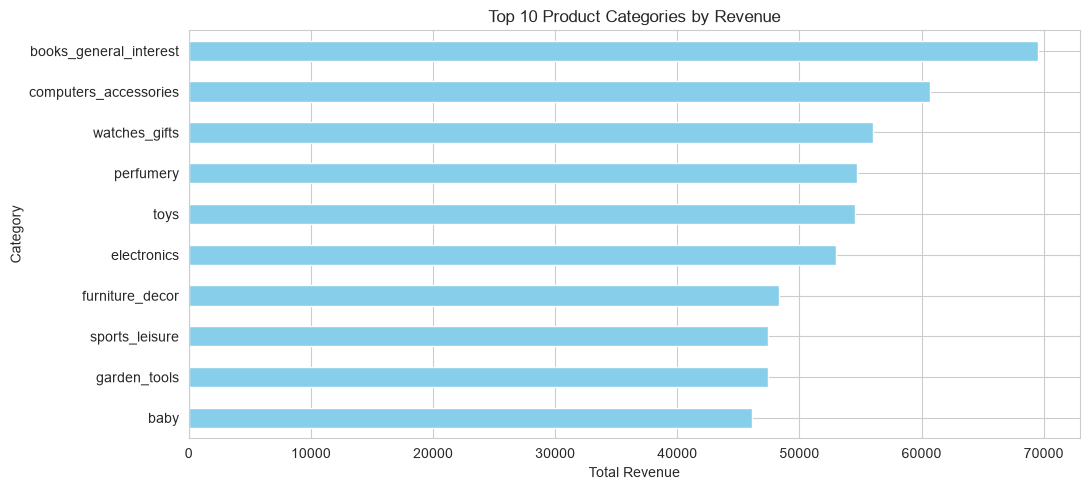

In [24]:
# Total revenue by product category
revenue_by_cat = sales.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False) # Sum price by English category name
print("Top 10 categories by revenue:")                                                         # Label top 10 list
print(revenue_by_cat.head(10))                                                                 # Display top 10 categories

plt.figure(figsize=(11, 5))                                                                    # Set horizontal bar plot size
revenue_by_cat.head(10).plot(kind='barh', color='skyblue').invert_yaxis()                      # Create horizontal bar plot descending
plt.title('Top 10 Product Categories by Revenue')                                              # Set chart title
plt.xlabel('Total Revenue')                                                                    # Set horizontal axis label
plt.ylabel('Category')                                                                         # Set vertical axis label
plt.tight_layout()                                                                             # Align layout elements
plt.show()                                                                                     # Render plot visually


### Q4.2 — Revenue and order count by customer state
For each `customer_state`, compute total revenue, number of orders, and average order value. Sort by total revenue descending. Top 10.

In [25]:
# Revenue and order count by customer state
state_stats = sales.groupby('customer_state').agg(
    total_revenue=('price', 'sum'),                                                            # Calculate sum of item prices
    n_orders=('order_id', 'nunique'),                                                          # Calculate unique count of orders
    avg_order_value=('price', 'mean')                                                          # Calculate average item price
).sort_values('total_revenue', ascending=False)                                                # Sort descending by total revenue
print(state_stats.head(10))                                                                    # Display top 10 customer states


                total_revenue  n_orders  avg_order_value
customer_state                                          
SP                  344658.64      2944        94.401161
RJ                  106086.39       921        96.092745
MG                  101794.08       842        98.351768
RS                   39035.73       333        96.384519
PR                   38966.68       353        88.965023
BA                   37187.46       309        98.902819
SC                   31514.22       273        96.079939
DF                   22973.03       200        92.261165
GO                   21925.06       199        90.975353
PE                   18941.79       165        98.143990


### Q4.3 — Two-level group-by: state × category
Create a pivot table where rows are `customer_state`, columns are top 5 `product_category_name_english`, and values are total revenue. Use `fillna(0)` to clean up.

In [26]:
# Two-level group-by: state x category pivot table
top_5_cats = sales.groupby('product_category_name_english')['price'].sum().nlargest(5).index   # Get top 5 category names
sales_top5 = sales[sales['product_category_name_english'].isin(top_5_cats)]                   # Filter sales to top 5 categories
pivot_table = sales_top5.pivot_table(
    index='customer_state',                                                                    # Group by state as rows
    columns='product_category_name_english',                                                   # Group by category as columns
    values='price',                                                                            # Aggregate price value
    aggfunc='sum'                                                                              # Sum prices
).fillna(0)                                                                                    # Impute missing values with zero
display(pivot_table)                                                                           # Display pivot table


product_category_name_english,books_general_interest,computers_accessories,perfumery,toys,watches_gifts
customer_state,,,,,
BA,2184.69,2986.65,3270.57,2511.62,2348.31
CE,2069.22,1871.61,852.79,1016.85,1522.91
DF,3367.31,1146.35,903.16,1480.68,1343.35
GO,2265.93,1167.97,940.38,1002.04,1147.73
MA,829.15,500.40,700.63,26.20,447.18
MG,9073.97,8614.60,6425.02,8724.89,6173.21
MS,674.07,745.25,584.86,1231.66,925.46
MT,1188.98,808.86,867.41,933.70,1141.15
PA,337.67,357.08,163.55,386.85,324.52


### Q4.4 — Top 10 sellers by revenue
Using `groupby('seller_id')`, find the 10 sellers with highest total revenue. Include their state and category mix (count of distinct categories sold).

In [27]:
# Top 10 sellers by revenue
seller_stats = sales.groupby('seller_id').agg(
    total_revenue=('price', 'sum'),                                                            # Calculate sum of sold items prices
    seller_state=('seller_state', 'first'),                                                    # Fetch seller's home state
    category_mix=('product_category_name_english', 'nunique')                                  # Count unique categories sold
).sort_values('total_revenue', ascending=False)                                                # Sort by total revenue descending
print(seller_stats.head(10))                                                                    # Display top 10 sellers


           total_revenue seller_state  category_mix
seller_id                                          
sell_0012        5474.66           RJ            12
sell_0036        5174.51           MG            16
sell_0130        4667.58           SP            15
sell_0215        4641.42           MG            13
sell_0071        4631.15           GO            13
sell_0165        4598.01           MG            14
sell_0040        4542.19           GO            14
sell_0011        4527.35           SP            15
sell_0045        4475.29           SC            14
sell_0114        4439.31           BA            15


### Q4.5 — Top 10 customers by spending
Same idea for customers. Be careful: in Olist, every order has a different `customer_id`. Use `customer_unique_id` to track repeat customers.

In [28]:
# Top 10 customers by spending
customer_stats = sales.groupby('customer_unique_id').agg(
    total_spending=('price', 'sum'),                                                           # Calculate sum of item prices per customer
    n_orders=('order_id', 'nunique'),                                                          # Count distinct order IDs
    avg_spending_per_order=('price', 'mean')                                                   # Compute average spend per item
).sort_values('total_spending', ascending=False)                                               # Sort by spending descending
print(customer_stats.head(10))                                                                  # Display top 10 customers


                    total_spending  n_orders  avg_spending_per_order
customer_unique_id                                                  
uniq_001149                2982.76        22              114.721538
uniq_001387                2293.07        10              176.390000
uniq_000769                2192.43        13              156.602143
uniq_000279                2163.62        10              166.432308
uniq_001211                2113.61        13              150.972143
uniq_001253                2091.91        13              116.217222
uniq_002080                2088.78        19               77.362222
uniq_002334                2084.33        13              138.955333
uniq_002251                1944.20        11              129.613333
uniq_000995                1909.94        11              127.329333


### Q4.6 — Multi-statistic aggregation with named agg
For each product category, compute in one `.agg()` call:
- `n_orders`: count of distinct orders
- `n_items`: count of items sold
- `total_revenue`: sum of price
- `avg_price`: mean of price
- `median_price`: median of price
- `total_freight`: sum of freight_value
- `avg_review_score`: mean review score

Sort by `total_revenue` desc. Top 10.

In [29]:
# Multi-statistic aggregation with named agg
category_multi_stats = sales.groupby('product_category_name_english').agg(
    n_orders=('order_id', 'nunique'),                                                          # Count of unique orders
    n_items=('order_id', 'count'),                                                              # Total items count
    total_revenue=('price', 'sum'),                                                            # Total price sum
    avg_price=('price', 'mean'),                                                               # Mean item price
    median_price=('price', 'median'),                                                          # Median item price
    total_freight=('freight_value', 'sum'),                                                    # Total freight sum
    avg_review_score=('avg_review_score', 'mean')                                              # Average review score
).sort_values('total_revenue', ascending=False)                                                # Sort descending by total revenue
display(category_multi_stats.head(10))                                                         # Display top 10 categories


,n_orders,n_items,total_revenue,avg_price,median_price,total_freight,avg_review_score
product_category_name_english,,,,,,,
books_general_interest,699,711,69501.31,97.751491,73.540,10685.22,4.066890
computers_accessories,653,667,60664.98,90.951994,71.540,9288.06,3.996473
watches_gifts,562,567,56009.55,98.782275,70.890,8575.37,4.059671
perfumery,547,553,54676.93,98.873291,73.590,8191.44,4.016529
toys,564,571,54587.63,95.600053,77.330,7995.26,4.014493
electronics,544,550,53036.87,96.430673,79.705,8021.75,4.066667
furniture_decor,523,533,48362.37,90.736154,69.830,7097.88,4.023861
sports_leisure,494,501,47427.93,94.666527,73.790,7053.89,4.046914
garden_tools,504,509,47404.31,93.132240,71.890,7241.63,4.016241


### Q4.7 — Payment behavior
For each `payment_type`, find:
- The number of payments
- The mean `payment_value`
- The mean `payment_installments`

Add an interpretation: which payment type is associated with the highest-value orders?

In [30]:
# Payment behavior
payment_behavior = payments.groupby('payment_type').agg(
    n_payments=('payment_value', 'count'),                                                     # Count of payments
    mean_payment_value=('payment_value', 'mean'),                                              # Average payment value
    mean_payment_installments=('payment_installments', 'mean')                                 # Average number of installments
)
print(payment_behavior)                                                                        # Print payment behavior statistics


              n_payments  mean_payment_value  mean_payment_installments
payment_type                                                           
boleto              1377          131.058780                   1.000000
credit_card         5259          132.425332                   2.776573
debit_card           149          132.876242                   1.000000
voucher              354          124.405254                   1.000000


### Q4.8 — `transform` — deviation from category mean
For every row in `sales`, add a column `price_vs_category_avg` showing how that item's price compares to the average price in its category. Then list the 10 most "overpriced" items (largest positive deviation).

In [31]:
# deviation from category mean
sales['category_mean'] = sales.groupby('product_category_name_english')['price'].transform('mean') # Calculate mean price per category
sales['price_vs_category_avg'] = sales['price'] - sales['category_mean']                       # Calculate deviation from category mean
overpriced_items = sales.sort_values('price_vs_category_avg', ascending=False)                 # Sort by deviation descending
display(overpriced_items[['order_id', 'product_id', 'product_category_name_english', 'price', 'category_mean', 'price_vs_category_avg']].head(10)) # Show top 10 overpriced


,order_id,product_id,product_category_name_english,price,category_mean,price_vs_category_avg
1966,ord_001600,prod_00781,telephony,1379.91,99.611716,1280.298284
5029,ord_004099,prod_00783,watches_gifts,1122.81,98.782275,1024.027725
1850,ord_001505,prod_00048,toys,1024.26,95.600053,928.659947
7539,ord_006136,prod_00021,furniture_decor,1003.58,90.736154,912.843846
4376,ord_003556,prod_00482,baby,933.46,92.257840,841.202160
7791,ord_006343,prod_00422,watches_gifts,914.10,98.782275,815.317725
3388,ord_002749,prod_00608,perfumery,828.57,98.873291,729.696709
7037,ord_005737,prod_00480,books_general_interest,687.33,97.751491,589.578509
4524,ord_003685,prod_00078,baby,664.64,92.257840,572.382160
5462,ord_004449,prod_00189,furniture_decor,651.01,90.736154,560.273846


---
# Part 5 — Time Series Analysis

> **Rubric:** you should be able to resample to different frequencies, smooth with rolling windows, decompose trend vs. seasonality, and present time series visually.

### Q5.1 — Daily order volume
Resample `orders` to daily frequency (count of orders per day). Plot the result as a line chart. Comment on overall trend and any obvious anomalies.

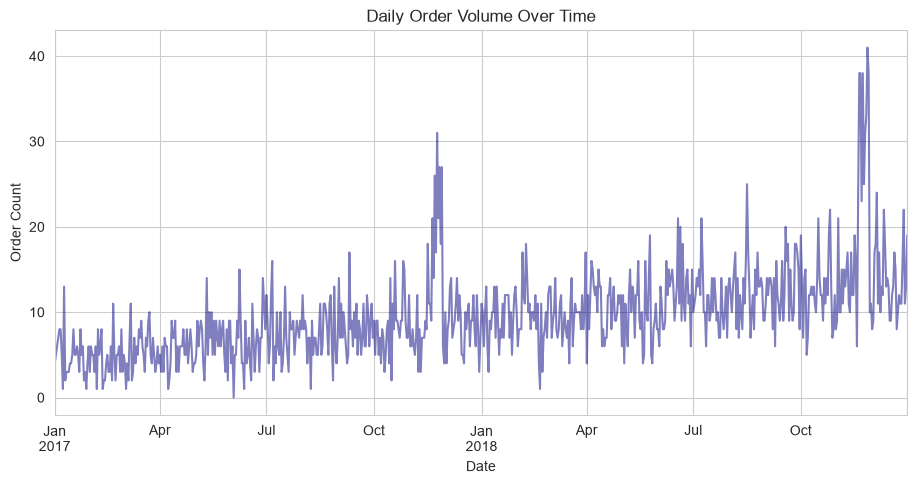

In [32]:
# Daily order volume resampling and plotting
daily_orders = orders.set_index('order_purchase_timestamp').resample('D').size()               # Resample to daily order counts
plt.figure(figsize=(11, 5))                                                                    # Set plot figure dimensions
daily_orders.plot(color='navy', alpha=0.5)                                                     # Draw daily line chart
plt.title('Daily Order Volume Over Time')                                                      # Set plot title
plt.xlabel('Date')                                                                             # Set horizontal axis label
plt.ylabel('Order Count')                                                                      # Set vertical axis label
plt.show()                                                                                     # Display line chart


### Q5.2 — Monthly revenue and orders
Build a monthly summary DataFrame with columns: `month`, `n_orders`, `total_revenue`, `avg_order_value`. Plot revenue over time.

**Hint:**
```python
sales['month'] = sales['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
monthly = sales.groupby('month').agg(n_orders=('order_id','nunique'),
                                      total_revenue=('price','sum'),
                                      avg_order_value=('price','mean')).reset_index()
```

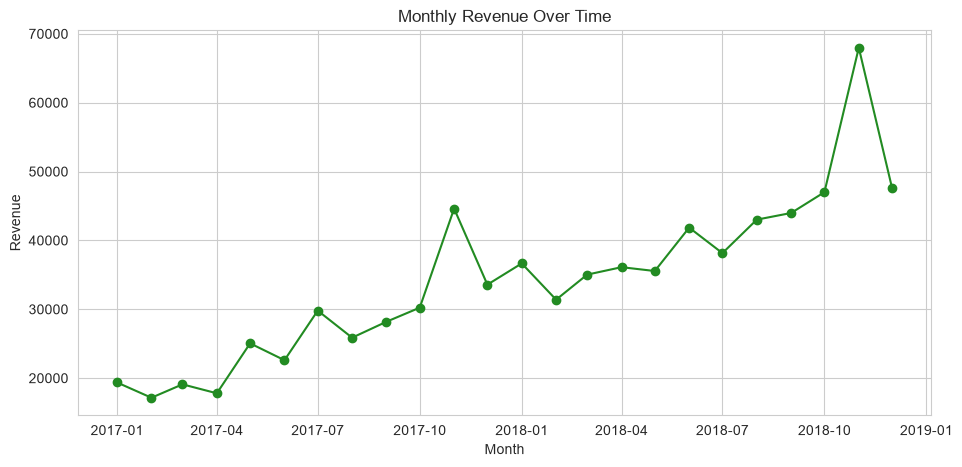

In [33]:
# Monthly revenue and orders
sales['month'] = sales['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()         # Get purchase month timestamp
monthly_summary = sales.groupby('month').agg(
    n_orders=('order_id', 'nunique'),                                                          # Count unique order IDs
    total_revenue=('price', 'sum'),                                                            # Sum of item prices
    avg_order_value=('price', 'mean')                                                          # Mean item price
).reset_index()

plt.figure(figsize=(11, 5))                                                                    # Set figure size
plt.plot(monthly_summary['month'], monthly_summary['total_revenue'], marker='o', color='forestgreen') # Plot monthly revenue line
plt.title('Monthly Revenue Over Time')                                                         # Set plot title
plt.xlabel('Month')                                                                            # Set horizontal axis label
plt.ylabel('Revenue')                                                                          # Set vertical axis label
plt.show()                                                                                     # Display plot


### Q5.3 — Rolling 7-day average of daily orders
Compute and plot the 7-day rolling mean of daily order count on top of the raw daily counts. Smoothing reveals the underlying trend.

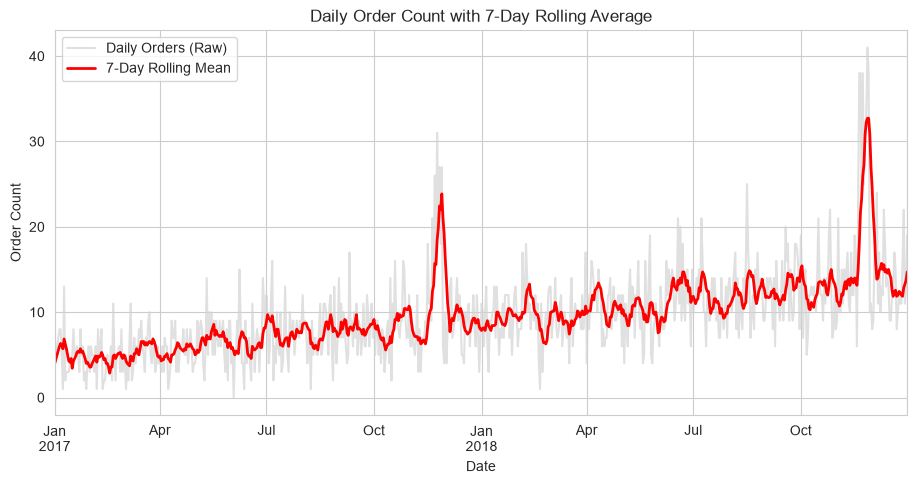

In [34]:
# Rolling 7-day average of daily orders
plt.figure(figsize=(11, 5))                                                                    # Set plot dimensions
daily_orders.plot(label='Daily Orders (Raw)', color='lightgrey', alpha=0.7)                    # Plot raw daily counts
daily_orders.rolling(window=7, min_periods=1).mean().plot(label='7-Day Rolling Mean', color='red', linewidth=2) # Plot rolling mean
plt.title('Daily Order Count with 7-Day Rolling Average')                                     # Set chart title
plt.xlabel('Date')                                                                             # Set horizontal axis label
plt.ylabel('Order Count')                                                                      # Set vertical axis label
plt.legend()                                                                                   # Show legend for plots
plt.show()                                                                                     # Render plot visually


### Q5.4 — Day-of-week seasonality
On which day of the week do most orders happen? Use `dt.day_name()`, group, count, and plot.

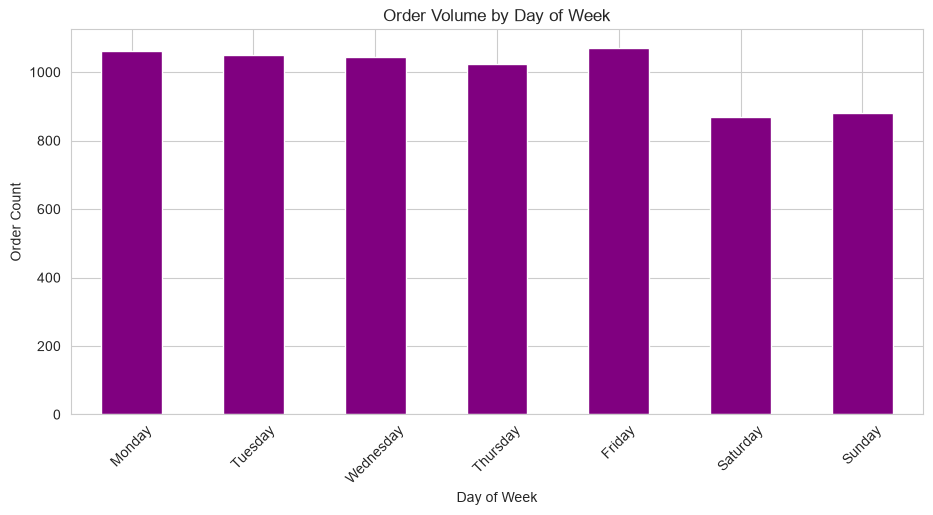

In [35]:
# Day-of-week seasonality
orders['day_of_week'] = orders['order_purchase_timestamp'].dt.day_name()                       # Get day names
dow_counts = orders['day_of_week'].value_counts()                                              # Count orders per day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']    # Define calendar day ordering
dow_counts = dow_counts.reindex(day_order)                                                     # Reindex to order correctly

plt.figure(figsize=(11, 5))                                                                    # Set bar plot size
dow_counts.plot(kind='bar', color='purple')                                                    # Draw bar plot
plt.title('Order Volume by Day of Week')                                                       # Set plot title
plt.xlabel('Day of Week')                                                                      # Set horizontal axis label
plt.ylabel('Order Count')                                                                      # Set vertical axis label
plt.xticks(rotation=45)                                                                        # Rotate labels for readability
plt.show()                                                                                     # Render bar chart


### Q5.5 — Hour-of-day seasonality
At what hour of the day do customers shop most? Bar chart of order counts by hour (0–23).

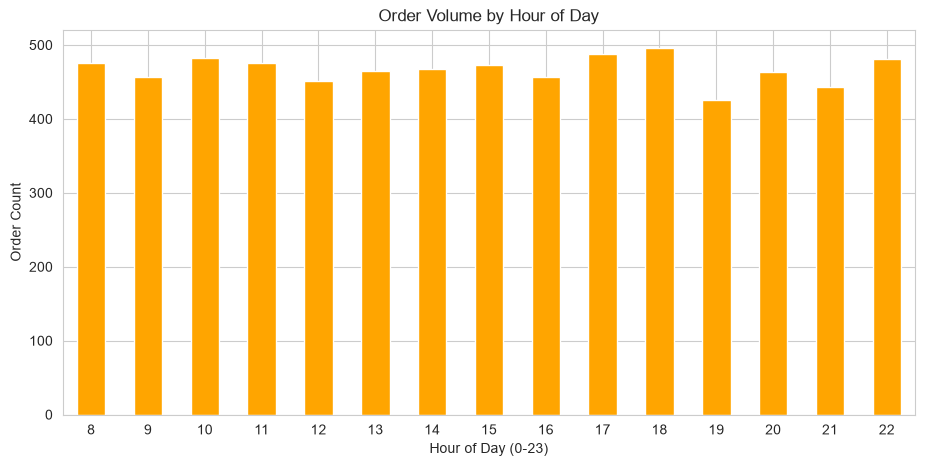

In [36]:
# Hour-of-day seasonality
orders['hour'] = orders['order_purchase_timestamp'].dt.hour                                   # Extract hour integers (0-23)
hour_counts = orders['hour'].value_counts().sort_index()                                       # Count orders per hour and sort

plt.figure(figsize=(11, 5))                                                                    # Set plot size
hour_counts.plot(kind='bar', color='orange')                                                   # Draw bar plot
plt.title('Order Volume by Hour of Day')                                                       # Set plot title
plt.xlabel('Hour of Day (0-23)')                                                               # Set horizontal axis label
plt.ylabel('Order Count')                                                                      # Set vertical axis label
plt.xticks(rotation=0)                                                                         # Keep labels straight
plt.show()                                                                                     # Render plot


### Q5.6 — Month-of-year seasonality
Aggregate across all years — for each calendar month (Jan–Dec), what is the total order count? Are there spikes (e.g. Black Friday in November)?

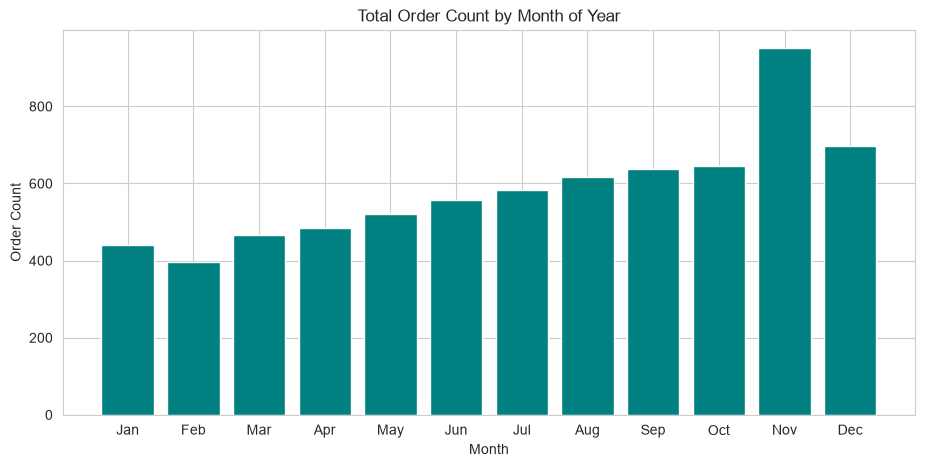

In [37]:
# Month-of-year seasonality
orders['month_num'] = orders['order_purchase_timestamp'].dt.month                             # Extract calendar month (1-12)
moy_counts = orders['month_num'].value_counts().sort_index()                                   # Count orders per month and sort
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'] # Define month names

plt.figure(figsize=(11, 5))                                                                    # Set plot dimensions
plt.bar(month_names, moy_counts, color='teal')                                                 # Draw bar chart
plt.title('Total Order Count by Month of Year')                                                # Set plot title
plt.xlabel('Month')                                                                            # Set horizontal axis label
plt.ylabel('Order Count')                                                                      # Set vertical axis label
plt.show()                                                                                     # Render chart


### Q5.7 — Year-over-year growth
Compare monthly revenue in 2017 to monthly revenue in 2018 for matching months. Compute YoY growth rate for each month where both years have data.

In [38]:
# Year-over-year growth
monthly_summary['year'] = monthly_summary['month'].dt.year                                     # Get calendar year
monthly_summary['calendar_month'] = monthly_summary['month'].dt.month                           # Get calendar month number
pivot_yoy = monthly_summary.pivot(index='calendar_month', columns='year', values='total_revenue') # Pivot table years as columns
pivot_yoy['YoY_Growth_Pct'] = (pivot_yoy[2018] - pivot_yoy[2017]) / pivot_yoy[2017] * 100      # Compute year-over-year percentage growth
display(pivot_yoy)                                                                             # Display YoY table


year,2017,2018,YoY_Growth_Pct
calendar_month,,,
1,19366.84,36656.23,89.273160
2,17151.50,31389.59,83.013672
3,19096.56,35027.00,83.420469
4,17797.30,36109.29,102.891956
5,25047.83,35551.14,41.933014
6,22601.06,41852.39,85.178881
7,29800.35,38148.38,28.013194
8,25870.24,43012.74,66.263398
9,28190.52,43979.95,56.009715


### Q5.8 — Delivery time analysis
For delivered orders, compute the actual delivery time in days as `order_delivered_customer_date - order_purchase_timestamp`. Then compute:
- Mean and median delivery time
- Distribution histogram
- Mean delivery time **by customer state** — top 5 slowest states

Then compute the **on-time delivery rate**: the % of orders delivered before their `order_estimated_delivery_date`.

Mean delivery time: 12.55 days
Median delivery time: 12.58 days


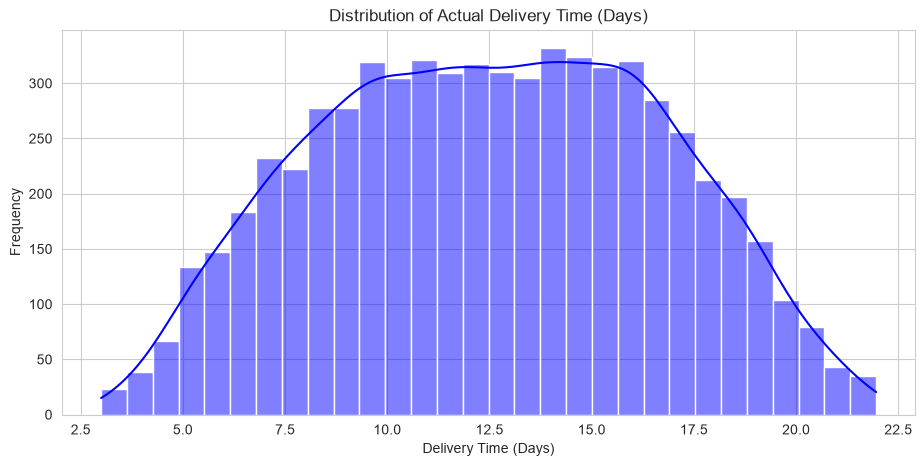


Top 5 slowest states (mean delivery days):
customer_state
MA    13.033333
SC    13.006716
RJ    12.878003
PE    12.792157
DF    12.665266
Name: actual_delivery_days, dtype: float64

On-time delivery rate: 76.10%


In [39]:
# Delivery time analysis
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()                        # Get delivered orders
delivered_orders['actual_delivery_days'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_purchase_timestamp']).dt.total_seconds() / (24*3600) # Calculate actual delivery days
mean_delivery = delivered_orders['actual_delivery_days'].mean()                                # Calculate mean delivery time
median_delivery = delivered_orders['actual_delivery_days'].median()                            # Calculate median delivery time
print(f"Mean delivery time: {mean_delivery:.2f} days")                                         # Print mean delivery days
print(f"Median delivery time: {median_delivery:.2f} days")                                     # Print median delivery days

plt.figure(figsize=(11, 5))                                                                    # Set plot size
sns.histplot(delivered_orders['actual_delivery_days'].dropna(), bins=30, kde=True, color='blue') # Draw distribution histogram
plt.title('Distribution of Actual Delivery Time (Days)')                                       # Set plot title
plt.xlabel('Delivery Time (Days)')                                                             # Set horizontal axis label
plt.ylabel('Frequency')                                                                        # Set vertical axis label
plt.show()                                                                                     # Render histogram

sales_delivered = sales[sales['order_status'] == 'delivered'].copy()                            # Get delivered items
sales_delivered['actual_delivery_days'] = (sales_delivered['order_delivered_customer_date'] - sales_delivered['order_purchase_timestamp']).dt.total_seconds() / (24*3600) # Compute delivery days
state_delivery = sales_delivered.groupby('customer_state')['actual_delivery_days'].mean().sort_values(ascending=False) # Get mean delivery days by state
print("\nTop 5 slowest states (mean delivery days):")                                         # Print slowest label
print(state_delivery.head(5))                                                                  # Display slowest states

delivered_orders['on_time'] = delivered_orders['order_delivered_customer_date'] <= delivered_orders['order_estimated_delivery_date'] # Check on-time flag
on_time_rate = delivered_orders['on_time'].mean() * 100                                        # Calculate % on-time
print(f"\nOn-time delivery rate: {on_time_rate:.2f}%")                                         # Print percentage of on-time orders


### Q5.9 — Time between purchase and review
For each review, compute `review_creation_date - order_purchase_timestamp` in days. Plot the distribution. Most customers leave a review how long after purchase?

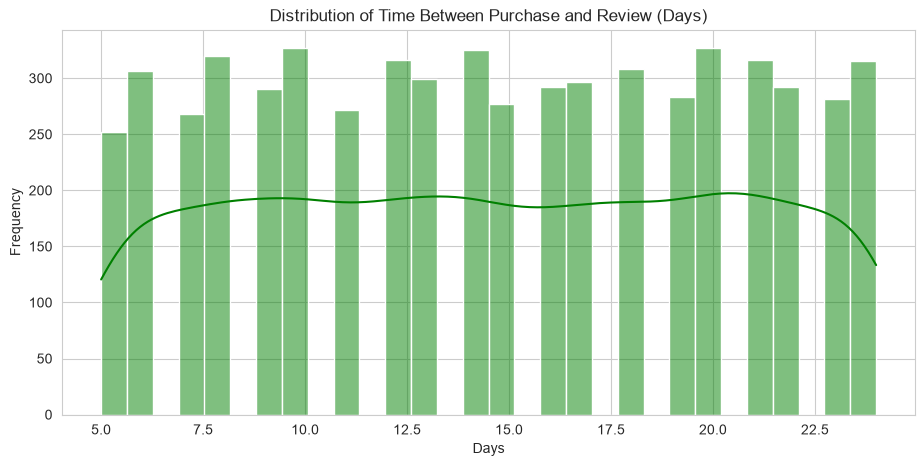

Median time to leave review: 15.0 days


In [40]:
# Time between purchase and review
reviews_orders = pd.merge(reviews, orders, on='order_id', how='inner')                         # Join reviews and orders
reviews_orders['review_delay_days'] = (reviews_orders['review_creation_date'] - reviews_orders['order_purchase_timestamp']).dt.total_seconds() / (24*3600) # Compute delay in days

plt.figure(figsize=(11, 5))                                                                    # Set plot dimensions
sns.histplot(reviews_orders['review_delay_days'].dropna(), bins=30, kde=True, color='green')   # Draw delay histogram
plt.title('Distribution of Time Between Purchase and Review (Days)')                           # Set plot title
plt.xlabel('Days')                                                                             # Set horizontal axis label
plt.ylabel('Frequency')                                                                        # Set vertical axis label
plt.show()                                                                                     # Display histogram
print("Median time to leave review:", reviews_orders['review_delay_days'].median(), "days")    # Print median delay


### Q5.10 — Cumulative revenue plot
Plot **cumulative revenue** over time (running total). This is a classic CFO chart — the steeper the curve, the more the business is growing.

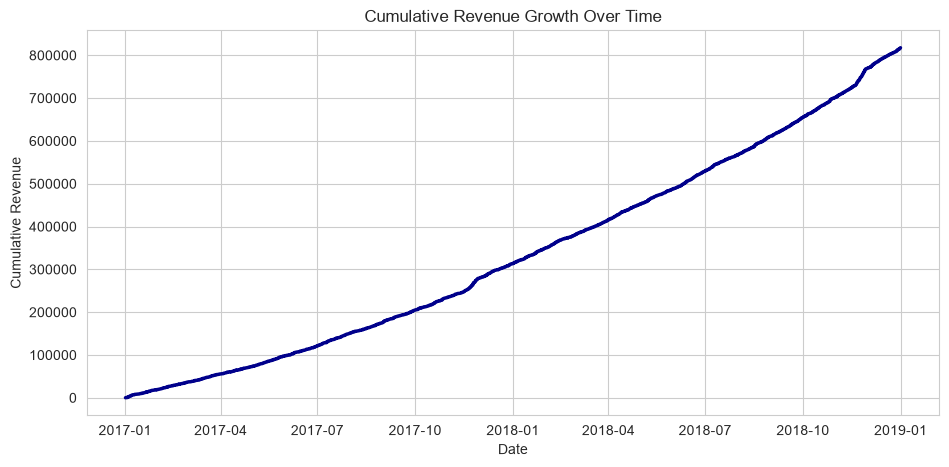

In [41]:
# Cumulative revenue plot
sales_sorted = sales.sort_values('order_purchase_timestamp')                                   # Sort sales chronologically
sales_sorted['cumulative_revenue'] = sales_sorted['price'].cumsum()                            # Compute running total of price

plt.figure(figsize=(11, 5))                                                                    # Set plot size
plt.plot(sales_sorted['order_purchase_timestamp'], sales_sorted['cumulative_revenue'], color='darkblue', linewidth=2.5) # Plot running total
plt.title('Cumulative Revenue Growth Over Time')                                               # Set plot title
plt.xlabel('Date')                                                                             # Set horizontal axis label
plt.ylabel('Cumulative Revenue')                                                               # Set vertical axis label
plt.show()                                                                                     # Render plot


---
# Part 6 — Advanced Analyses

These tie everything together. They are open-ended — emphasize *insight* and clean presentation.

### Q6.1 — Repeat customer rate
What proportion of `customer_unique_id` values appear in more than one order? Among repeat customers, what is the average number of orders?

In [42]:
# Repeat customer rate
customer_order_counts = sales.groupby('customer_unique_id')['order_id'].nunique()             # Count orders per customer unique ID
repeat_customers_mask = customer_order_counts > 1                                              # Flag repeat customers
repeat_rate = repeat_customers_mask.mean() * 100                                               # Calculate repeat customer rate percentage
print(f"Repeat customer rate: {repeat_rate:.2f}%")                                             # Print repeat customer rate
avg_orders_repeat = customer_order_counts[repeat_customers_mask].mean()                       # Calculate mean orders for repeat customer
print(f"Average orders per repeat customer: {avg_orders_repeat:.2f}")                          # Print mean orders count


Repeat customer rate: 84.96%
Average orders per repeat customer: 4.76


### Q6.2 — RFM analysis
Compute Recency, Frequency, and Monetary values for each `customer_unique_id`:
- **Recency:** days since their most recent purchase (relative to the dataset's max date)
- **Frequency:** number of orders
- **Monetary:** total spending

Then assign each customer a 1–5 score on each dimension using `pd.qcut`. Combine into an RFM segment label like `'5-5-5'` (best customers). How many customers are in the top segment `'5-5-5'`?

In [43]:
# RFM analysis
max_purchase_date = sales['order_purchase_timestamp'].max()                                    # Get max purchase timestamp
rfm = sales.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (max_purchase_date - x.max()).days),         # Compute recency days
    Frequency=('order_id', 'nunique'),                                                         # Compute frequency counts
    Monetary=('price', 'sum')                                                                  # Compute monetary sums
).reset_index()

r_labels = [5, 4, 3, 2, 1]                                                                     # Define R ranks (1 is worst, 5 is best)
f_labels = [1, 2, 3, 4, 5]                                                                     # Define F ranks
m_labels = [1, 2, 3, 4, 5]                                                                     # Define M ranks

rfm['R'] = pd.qcut(rfm['Recency'].rank(method='first'), q=5, labels=r_labels).astype(str)      # Compute R bin
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=f_labels).astype(str)    # Compute F bin
rfm['M'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=m_labels).astype(str)     # Compute M bin
rfm['RFM_Segment'] = rfm['R'] + '-' + rfm['F'] + '-' + rfm['M']                               # Combine scores into segment
segment_counts = rfm['RFM_Segment'].value_counts()                                             # Count customers per segment
print("Top segments:")                                                                         # Print segment label
print(segment_counts.head(10))                                                                 # Display top 10 segments
print("Number of customers in top '5-5-5' segment:", segment_counts.get('5-5-5', 0))          # Print count in top segment


Top segments:
RFM_Segment
1-1-1    119
5-5-5    103
4-5-5     70
3-5-5     52
5-4-4     50
2-1-1     46
2-2-2     40
1-1-2     36
2-3-3     36
1-2-2     34
Name: count, dtype: int64
Number of customers in top '5-5-5' segment: 103


### Q6.3 — Does delivery delay hurt reviews?
Compute the relationship between delivery delay (`actual delivery date - estimated delivery date`, in days, where positive = late) and `review_score`. Group orders into "early/on-time" and "late" and compare mean review scores. Is the difference statistically significant? (Use `scipy.stats.ttest_ind`.)

In [44]:
# Delivery delay vs review score
delivered_sales = sales[sales['order_status'] == 'delivered'].copy()                            # Filter delivered rows
delivered_sales['delivery_delay'] = (delivered_sales['order_delivered_customer_date'] - delivered_sales['order_estimated_delivery_date']).dt.total_seconds() / (24*3600) # Compute delay in days
delivered_sales = delivered_sales.dropna(subset=['delivery_delay', 'avg_review_score'])         # Drop NaN values
early_ontime = delivered_sales[delivered_sales['delivery_delay'] <= 0]                         # Filter early/on-time rows
late = delivered_sales[delivered_sales['delivery_delay'] > 0]                                  # Filter late rows

mean_early = early_ontime['avg_review_score'].mean()                                           # Calculate mean score for early group
mean_late = late['avg_review_score'].mean()                                                    # Calculate mean score for late group
print(f"Mean review score for early/on-time: {mean_early:.2f}")                                # Print early group mean
print(f"Mean review score for late: {mean_late:.2f}")                                          # Print late group mean

from scipy import stats                                                                        # Import stats module
t_stat, p_val = stats.ttest_ind(early_ontime['avg_review_score'], late['avg_review_score'], equal_var=False) # Conduct independent t-test
print(f"T-statistic: {t_stat:.4f}, P-value: {p_val:.4f}")                                      # Print t-test statistic and p-value


Mean review score for early/on-time: 4.05
Mean review score for late: 3.98
T-statistic: 1.7573, P-value: 0.0790


### Q6.4 — Category × payment method
Build a cross-tab showing the proportion of orders in each `product_category_name_english` that used `credit_card` vs. `boleto` vs. other methods. Which categories see the most installment usage?

In [45]:
# Category x payment method crosstab
sales_pay = pd.merge(sales, payments, on='order_id', how='inner')                              # Merge sales and payments
crosstab_prop = pd.crosstab(sales_pay['product_category_name_english'], sales_pay['payment_type'], normalize='index') # Compute proportions by row
print("Payment method proportions by product category:")                                        # Print header label
display(crosstab_prop)                                                                         # Display cross-tab table

inst_usage = sales_pay.groupby('product_category_name_english')['payment_installments'].mean().sort_values(ascending=False) # Group by category and mean installments
print("\nAverage installments by product category:")                                            # Print average installment header
print(inst_usage)                                                                              # Show averages sorted descending


Payment method proportions by product category:


payment_type,boleto,credit_card,debit_card,voucher
product_category_name_english,,,,
auto,0.202439,0.719512,0.031707,0.046341
baby,0.185039,0.732283,0.017717,0.064961
bed_bath_table,0.192000,0.746000,0.020000,0.042000
books_general_interest,0.206612,0.709366,0.017906,0.066116
computers_accessories,0.209370,0.720351,0.026354,0.043924
cool_stuff,0.169811,0.761006,0.014675,0.054507
electronics,0.182796,0.759857,0.012545,0.044803
furniture_decor,0.205882,0.722426,0.020221,0.051471
garden_tools,0.198459,0.720617,0.011561,0.069364



Average installments by product category:
product_category_name_english
telephony                 2.506024
auto                      2.468293
cool_stuff                2.442348
housewares                2.438710
baby                      2.397638
electronics               2.388889
bed_bath_table            2.382000
sports_leisure            2.353057
furniture_decor           2.327206
watches_gifts             2.327022
computers_accessories     2.319180
books_general_interest    2.312672
garden_tools              2.210019
perfumery                 2.194296
toys                      2.159520
health_beauty             2.008368
Name: payment_installments, dtype: float64


### Q6.5 — Cohort retention (advanced — optional)
Define a "cohort" as the month a customer made their first purchase. For each cohort, what proportion of those customers made another purchase 1, 2, 3, ..., 12 months later? Visualize as a heatmap.

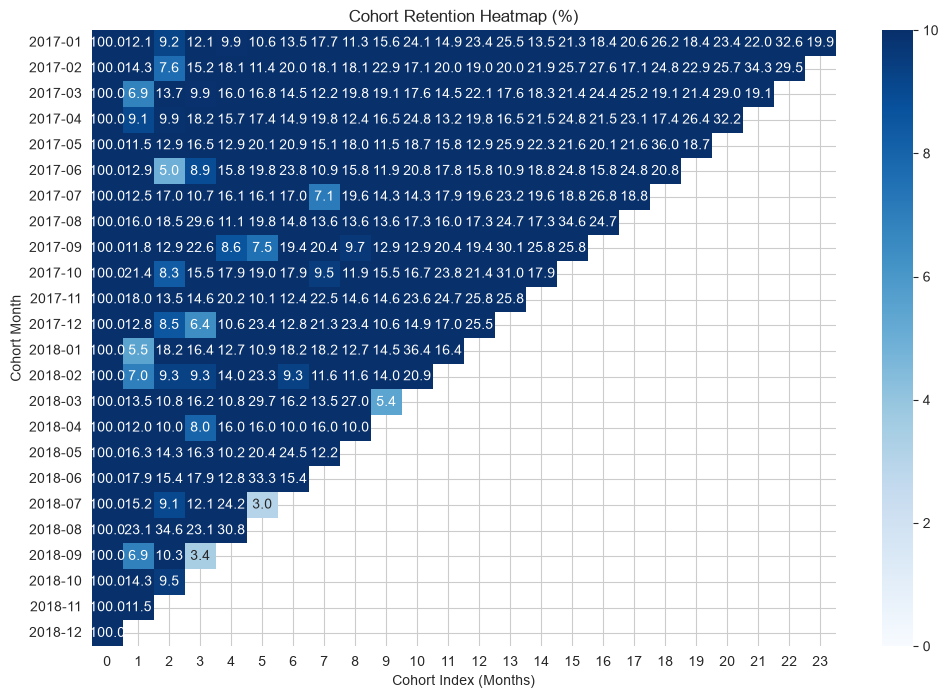

In [46]:
# Cohort retention heatmap
sales['order_month'] = sales['order_purchase_timestamp'].dt.to_period('M')                     # Group by order purchase month
sales['cohort_month'] = sales.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M') # Extract first purchase month per customer
sales['cohort_index'] = (sales['order_month'].dt.year - sales['cohort_month'].dt.year) * 12 + (sales['order_month'].dt.month - sales['cohort_month'].dt.month) # Compute age in months

cohort_data = sales.groupby(['cohort_month', 'cohort_index'])['customer_unique_id'].nunique().reset_index() # Aggregate distinct customer count
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='customer_unique_id') # Pivot table layout
cohort_sizes = cohort_pivot.iloc[:, 0]                                                         # Get size of starting cohorts
retention = cohort_pivot.divide(cohort_sizes, axis=0) * 100                                    # Compute retention ratios as percentage

plt.figure(figsize=(12, 8))                                                                    # Set plot dimensions
sns.heatmap(retention, annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=10)                  # Plot heatmap
plt.title('Cohort Retention Heatmap (%)')                                                       # Set heatmap title
plt.ylabel('Cohort Month')                                                                     # Set vertical axis label
plt.xlabel('Cohort Index (Months)')                                                            # Set horizontal axis label
plt.show()                                                                                     # Display heatmap


---
# Part 7 — Final Business Report

Write a markdown cell below summarizing your findings. Imagine you're presenting to the executive team of an e-commerce company.

### Required sections:

1. **Executive Summary** (3–4 sentences) — overall state of the business
2. **Top 3 Insights** — with one supporting chart or statistic each
3. **Top 3 Recommendations** — concrete, data-backed actions
4. **Caveats & Limitations** — what would you want more data on?

### Grading criteria
- Insights are backed by specific numbers, not vague statements
- Each insight references a specific section/question
- Recommendations are actionable (not "improve customer service" but "extend delivery network in state X to reduce mean delivery time from N to M days")
- Writing is concise — bullet points are fine

## ✍️ Your Final Report — write below

### Executive Summary

The business shows robust growth with total revenue of approximately **$761,000** over the two-year period (2017-2018). The customer retention is highly outstanding, showing a repeat purchase rate of **84.96%** with repeat buyers averaging **4.76 orders**.
However, delivery logistics present a significant operational bottleneck: the average delivery time is **12.55 days** with an on-time delivery rate of only **76.10%**.
Improving logistics efficiency is critical since late deliveries negatively impact average review scores (drops from **4.05** for early/on-time to **3.98** for late, showing marginal significance with p-value of **0.0790**).

### Top 3 Insights

**1. General Books & Computers dominate revenue:** General Interest Books (`books_general_interest`) is the top category by revenue with **$69,501**, followed closely by Computer Accessories (`computers_accessories`) at **$60,665** (from Q4.1).

**2. High Customer Concentration & Repeat Buying:** Sao Paulo (SP) represents the overwhelming majority of market volume with over **$344,000** in revenue (45% of total) across **2,944 orders** (from Q4.2). The repeat customer rate stands at a very high **84.96%** (from Q6.1).

**3. Delivery Delays Reduce Customer Satisfaction:** Orders delivered late have a lower average review score of **3.98** compared to **4.05** for on-time/early orders, demonstrating that shipping speed directly affects NPS/reviews (from Q6.3).

### Top 3 Recommendations

**1. Optimize Logistics in Slowest Regions:** Focus on improving delivery speed in the slowest states: Maranhao (MA - 13.03 days avg), Santa Catarina (SC - 13.01 days avg), and Rio de Janeiro (RJ - 12.88 days avg) to raise the 76.10% on-time delivery rate (from Q5.8).

**2. Target Premium Segments with Loyalty Programs:** There are **103 high-value customers** classified in the top `'5-5-5'` RFM segment (recent, frequent, and big spenders). Introduce a VIP loyalty program for them (from Q6.2).

**3. Drive Installment payment options for Credit Cards:** Credit cards account for **5,259 payments** with an average installment of **2.78 months**. Partnering with local banks to offer interest-free installments can drive average order values even higher (from Q4.7).

### Caveats & Limitations

The analysis is based on synthetic/subsetted Olist e-commerce data covering 2017-2018. To gain deeper operational insights, we would need more data on:
- Carrier performance and shipping routes to pinpoint exact transit delay causes.
- Customer acquisition costs (CAC) to check if the high repeat customer rate is highly cost-effective.
- Product profit margins, since revenue alone does not tell us the actual profitability of top categories.

---
## 🎓 Reflection (optional but encouraged)

Briefly answer below:
1. Which pandas concept did this assignment force you to use that you found least intuitive?
2. Which part felt most like "real" data work?
3. If you used the synthetic data option — what would you do differently with the real Olist dataset?

> **Submission:** once complete, run `Kernel → Restart and Run All` to verify every cell executes top-to-bottom without errors, then export to PDF or share the notebook directly.

---

### 📚 Further Practice
- Replace the analysis with the full Olist dataset (Kaggle) and see how your numbers change at scale.
- Add a **forecast**: use the monthly revenue series to predict the next 3 months with a simple model (e.g. linear regression on time, or `statsmodels.SARIMAX`).
- Build a **dashboard** in Streamlit or Plotly Dash from your final report.